- 코퍼스(corpus): 분석 대상이 되는 텍스트 전체 집합입니다.
- 문서(document): 코퍼스 안의 한 단위 텍스트입니다.
- 문장(sentence): 문서 내부의 문장 단위입니다.
- 토큰(token): 토큰화(tokenization) 후 얻는 최소 분석 단위입니다. 보통 단어, 형태소, 서브워드가 될 수 있습니다.
- 타입(type): 서로 다른 고유 토큰의 개수입니다.
- 어휘(vocabulary): 코퍼스에 등장한 모든 고유 토큰의 집합입니다.
- 토큰 수(token count): 문서 또는 코퍼스 전체에서 실제 등장한 토큰의 총 개수입니다.
- 문서 길이(document length): 한 문서에 포함된 토큰의 수입니다.
- 희소성(sparsity): 전체 가능한 단어 공간에 비해 실제 등장한 값이 매우 적은 정도입니다.

In [1]:
import nltk
from nltk.tokenize import word_tokenize
import numpy as np

In [2]:
# 코퍼스정의
corpus = {
    "나는 자연어 처리를 공부한다",
    "자연어 처리는 재미있다",
    "나는 데이터 분석과 자연어 처리를 함께 공부한다"
}
# 공백기준 단순 토큰화
tokenize_corpus = [doc.split() for doc in corpus]
tokenize_corpus

[['나는', '자연어', '처리를', '공부한다'],
 ['자연어', '처리는', '재미있다'],
 ['나는', '데이터', '분석과', '자연어', '처리를', '함께', '공부한다']]

In [3]:
doc_length = [len(token) for token in tokenize_corpus]

N = len(corpus) # 총 문서수
T = sum(doc_length) # 코퍼스 전체 토큰 수

# 평균 문서의 수
mean_legth = T / N
print(mean_legth)

4.666666666666667


In [4]:
# 어휘 집합
vocabulary = set()
for tokens in tokenize_corpus:
    vocabulary.update(tokens)
print(f'vocabulary : {vocabulary}')
V_size = len(vocabulary)
print(f'어휘 수 : {V_size}')
# TTR
TTR = V_size / T
print(f'타입/토큰비율 : {TTR}')

vocabulary : {'공부한다', '자연어', '처리는', '재미있다', '데이터', '분석과', '처리를', '나는', '함께'}
어휘 수 : 9
타입/토큰비율 : 0.6428571428571429


In [5]:
# 토큰 빈도와 단어 빈도분포, 희소성
from collections import Counter
# 전체 토큰을 하나의 리스트로 합침
all_tokens = [token for tokens in tokenize_corpus for token in tokens]
token_freq = Counter(all_tokens)
print(f'토큰 빈도 : {token_freq}')

# 문서-단어 행렬에서 관측값 계산 -> 각 문서내의 고유 단어 등장 수 합계
non_zero_cells = sum(len(set(tokens)) for tokens in tokenize_corpus)
total_cells = N * V_size # 문서수 * 어휘수(|V|)
density = non_zero_cells / total_cells
sparsity = 1 - density
print(f'희소성 : {sparsity:.4f}')
print(f'문서-단어 행렬 전체 칸 수 : {total_cells}')
print(f'값이 있는 칸 수 : {non_zero_cells}')
print(f'밀도 : {density:.4f}')

토큰 빈도 : Counter({'자연어': 3, '나는': 2, '처리를': 2, '공부한다': 2, '처리는': 1, '재미있다': 1, '데이터': 1, '분석과': 1, '함께': 1})
희소성 : 0.4815
문서-단어 행렬 전체 칸 수 : 27
값이 있는 칸 수 : 14
밀도 : 0.5185


In [6]:
import matplotlib.pyplot as plt
from nltk.corpus import gutenberg
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords # 불용어

# 데이터 다운로드
nltk.download('gutenberg')
nltk.download('stopwords')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Playdata\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
# 이상한 나라 앨리스 코퍼스 로드
doc_alice = gutenberg.raw('carroll-alice.txt')
# 정규식을 이용해서 3글자 이상 단어 추출 및 소문자
tokenizer = RegexpTokenizer(r"[\w']{3,}")
reg_tokens_alice = tokenizer.tokenize(doc_alice.lower())
# 불용어 제거
english_stops = stopwords.words('english')
result_alice = [word for word in reg_tokens_alice if word not in english_stops]

# 토큰 빈도 집계
alice_word_count = Counter(result_alice)
print(f'사용된 고유 단어 수 : {len(alice_word_count)}')

사용된 고유 단어 수 : 2671


In [8]:
top_20_words = alice_word_count.most_common(20)
print(f'상위 20개 고빈도 단어 : {top_20_words}')

상위 20개 고빈도 단어 : [('said', 462), ('alice', 385), ('little', 128), ('one', 98), ('know', 88), ('like', 85), ('went', 83), ('would', 78), ('could', 77), ('thought', 74), ('time', 71), ('queen', 68), ('see', 67), ('king', 61), ('began', 58), ('turtle', 57), ("'and", 56), ('way', 56), ('mock', 56), ('quite', 55)]


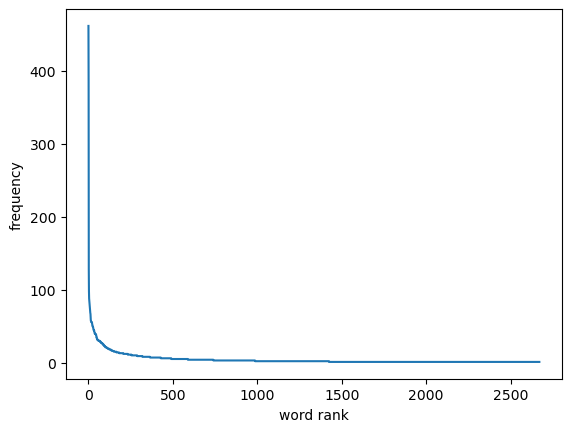

In [9]:
all_requenceis = sorted(list(alice_word_count.values()), reverse=True)
plt.plot(all_requenceis)
plt.xlabel('word rank')
plt.ylabel('frequency')
plt.show()